# Аггрегация данных #

Пришло время собрать всю информацию воендино и провесети анализ

In [1]:
! git clone https://github.com/mnedo/SMADIMO_GP2/

Cloning into 'SMADIMO_GP2'...
remote: Enumerating objects: 200, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 200 (delta 52), reused 19 (delta 19), pack-reused 129 (from 1)
Receiving objects: 100% (200/200), 4.30 MiB | 11.56 MiB/s, done.
Resolving deltas: 100% (99/99), done.


## Загрзка собранных раннее данных ##

In [2]:
import pandas as pd

In [6]:
cities = pd.read_excel('/content/SMADIMO_GP2/data/cities.xlsx')
cities.head(3)

,Город,Регион,Федеральный округ,Население,Наличие аэропорта
0,Абакан,Хакасия,Сибирский,184284,True
1,Анадырь,Чукотский АО,Дальневосточный,13224,True
2,Анапа,Краснодарский край,Южный,84804,True


In [7]:
cities = cities[cities['Наличие аэропорта'] == True]

In [8]:
hotels = pd.read_excel('/content/SMADIMO_GP2/data/hotels.xlsx')
hotels.head(3)

,city_name,hotel_name,reviews_count,rating_value,price_per_night,latitude,longitude
0,Абакан,Гостиница Хакасия,98.0,8.2,5540,53.722572,91.44298
1,Абакан,AZIMUT Отель Абакан 3*,16.0,9.3,4828,53.721160,91.43992
2,Абакан,Уютная Квартира в Центре Города,19.0,9.7,2666,53.719868,91.42204


In [9]:
hotels = hotels[hotels['latitude'].notna()]
hotels = hotels[hotels['rating_value'].notna()]
hotels = hotels[hotels['rating_value'] > 0]

In [10]:
sightseens = pd.read_csv('/content/SMADIMO_GP2/data/sightseens.csv')
sightseens.head(3)

,city,rubric,name,lat,lon,rating,review_count
0,Абакан,Рестораны,"STIX, бельгийский ресторан",53.721736,91.444138,4.7,648
1,Абакан,Рестораны,"Мажор, караоке-бар",53.725752,91.456086,4.7,307
2,Абакан,Рестораны,"Мадрид, кафе",53.727392,91.437827,4.6,300


In [11]:
sightseens = sightseens[sightseens['lat'].notna()]
sightseens = sightseens[sightseens['rating'].notna()]
sightseens = sightseens[sightseens['rating'] > 0]

In [12]:
flights = pd.read_excel('/content/SMADIMO_GP2/data/flights.xlsx')
flights.head(3)

,from_city,from_code,to_city,to_code,price,duration
0,Абакан,ABA,Анадырь,DYR,39655,2850
1,Абакан,ABA,Барнаул,BAX,11714,175
2,Абакан,ABA,Владивосток,VVO,20241,2015


## Стоимость путшествия ##

In [13]:
flights = flights.merge(cities[['Город', 'Население']].rename(columns={'Город': 'from_city'}), on='from_city', how='left')
flights = flights.rename(columns={'Население': 'from_population'})

In [14]:
# to-delete
flights = flights[flights['from_population'].notna()]
hotels = hotels[hotels['rating_value'].notna()]

In [15]:
gr = flights.groupby(by=['to_city']).agg({'from_population': 'sum'}).rename(columns={'from_population': 'total_population'}).reset_index()
flights = flights.merge(gr, on='to_city')
flights.head(2)

,from_city,from_code,to_city,to_code,price,duration,from_population,total_population
0,Абакан,ABA,Анадырь,DYR,39655,2850,184284,27012508
1,Абакан,ABA,Барнаул,BAX,11714,175,184284,44218534


In [16]:
flights['from_city_importance'] = flights['from_population']/flights['total_population']
flights['mult_ptice'] = flights['from_city_importance'] * flights['price']


In [17]:
flights_res = flights.groupby(by=['to_city']).agg({'mult_ptice': 'sum'}).reset_index().rename(columns={'to_city': 'city_name', 'mult_ptice': 'flight_price_weighted'})
flights_res.head(2)

,city_name,flight_price_weighted
0,Абакан,15676.612617
1,Анадырь,25586.406434


In [18]:
rng, Imin = flights_res['flight_price_weighted'].max() - flights_res['flight_price_weighted'].min(), flights_res['flight_price_weighted'].min()
flights_res['flight_price_weighted'] = (flights_res['flight_price_weighted']-Imin)/rng

## Привлекательность местоположение

Для каждого города и типа достопримечательности у нас есть разное количество оценок. И конечно количество оценок должно иметь вес при учете средней оценки - рейтинга.

Введем коэффициент важности оценки: Доля от максимального количество оценок в city+rubric

In [19]:
gr = sightseens.groupby(by=['city', 'rubric']).agg({'review_count': 'max'}).rename(columns={'review_count': 'max_count'}).reset_index()
sightseens = sightseens.merge(gr, on=['city', 'rubric'])

In [20]:
sightseens['review_importance'] = sightseens['review_count']/sightseens['max_count']
sightseens['I'] = sightseens['rating']*sightseens['review_importance'] # total importance
rng, Imin = sightseens['I'].max() - sightseens['I'].min(), sightseens['I'].min()
sightseens['I'] = (sightseens['I']-Imin)/rng

In [21]:
import matplotlib.pyplot as plt

In [ ]:
help(plt.hist)

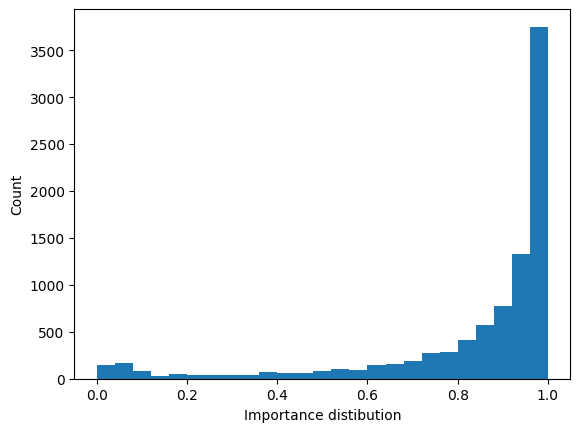

In [24]:
plt.hist(-sightseens['I']+1, range=(0, 1), bins=25)
plt.xlabel('Importance distibution')
plt.ylabel('Count')
plt.show()

In [25]:
calcdf = hotels[['city_name', 'hotel_name', 'latitude',	'longitude']].rename(columns={'city_name': 'city'}).merge(sightseens[['city', 'I', 'lat', 'lon', 'rubric']], on='city')
calcdf.head(3)

,city,hotel_name,latitude,longitude,I,lat,lon,rubric
0,Абакан,Гостиница Хакасия,53.722572,91.44298,0.560884,53.721736,91.444138,Рестораны
1,Абакан,Гостиница Хакасия,53.722572,91.44298,0.265727,53.725752,91.456086,Рестораны
2,Абакан,Гостиница Хакасия,53.722572,91.44298,0.254144,53.727392,91.437827,Рестораны


Мы будем использовать библиотеку geopy как доп. инструмент для расчета расстояния по широте и долготое: https://pypi.org/project/geopy/

In [26]:
pip install geopy

In [27]:
from geopy.distance import geodesic as dist

In [28]:
calcdf = calcdf.dropna()

In [29]:
calcdf['slagaemoe'] = calcdf.apply(lambda row: dist((row['latitude'], row['longitude']), (row['lat'], row['lon'])).km * (1-row['I']), axis=1)
calcdf.head(3)

,city,hotel_name,latitude,longitude,I,lat,lon,rubric,slagaemoe
0,Абакан,Гостиница Хакасия,53.722572,91.44298,0.560884,53.721736,91.444138,Рестораны,0.052878
1,Абакан,Гостиница Хакасия,53.722572,91.44298,0.265727,53.725752,91.456086,Рестораны,0.686331
2,Абакан,Гостиница Хакасия,53.722572,91.44298,0.254144,53.727392,91.437827,Рестораны,0.473773


In [30]:
gr = calcdf.groupby(by=['hotel_name', 'rubric']).agg({'slagaemoe': 'sum'}).rename(columns={'slagaemoe': 'weigthed_sum_atnes'}).reset_index()
rng, Imin = gr['weigthed_sum_atnes'].max() - gr['weigthed_sum_atnes'].min(), gr['weigthed_sum_atnes'].min()
gr['weigthed_sum_atnes'] =  1- (gr['weigthed_sum_atnes']-Imin)/rng

Посмотрим на распределение оценок по типам объектов привлечения
sources: https://github.com/mnedo/ML-intro_hse_2025/blob/main/hw_03_visualisation.ipynb (домашка ИАД)

In [31]:
import seaborn as sns

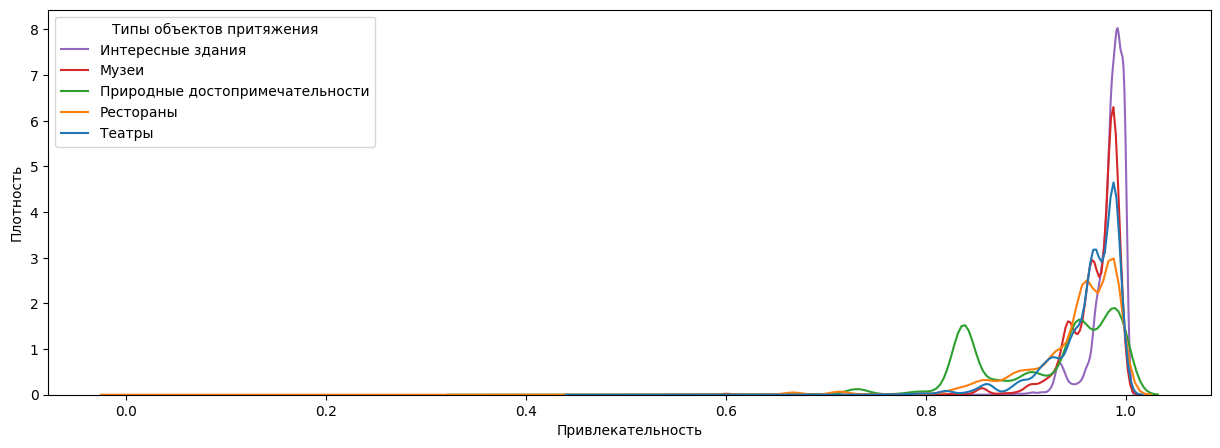

In [32]:
plt.figure(figsize=(15, 5))
sns.kdeplot(data=gr, x='weigthed_sum_atnes', hue='rubric')
plt.xlabel('Привлекательность')
plt.ylabel('Плотность')
plt.legend(title='Типы объектов притяжения', loc='upper left', labels=gr['rubric'].unique())
plt.show()

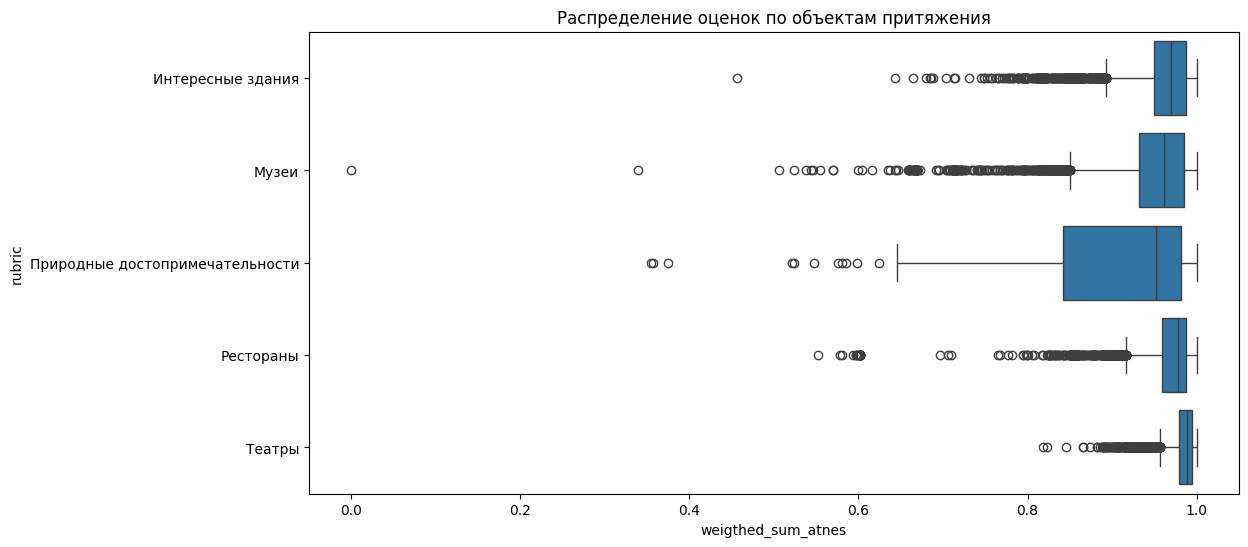

In [33]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='weigthed_sum_atnes', y='rubric', data=gr)
plt.title('Распределение оценок по объектам притяжения')
plt.show()

## Обогощение отелей ##

In [34]:
pvt = gr.pivot_table(index='hotel_name', columns='rubric', values='weigthed_sum_atnes').reset_index()
hotels_w = hotels[['city_name',	'hotel_name',	'reviews_count',	'rating_value',	'price_per_night']].merge(pvt, on='hotel_name', how='left')

In [35]:
hotels_w = hotels_w.merge(flights_res, on='city_name', how='left')
hotels_w.head(3)

,city_name,hotel_name,reviews_count,rating_value,price_per_night,Интересные здания,Музеи,Природные достопримечательности,Рестораны,Театры,flight_price_weighted
0,Абакан,Гостиница Хакасия,98.0,8.2,5540,0.796989,0.850455,0.888545,0.601418,0.961507,0.461033
1,Абакан,AZIMUT Отель Абакан 3*,16.0,9.3,4828,0.796733,0.850490,0.888501,0.601304,0.961509,0.461033
2,Абакан,Уютная Квартира в Центре Города,19.0,9.7,2666,0.794546,0.849853,0.888418,0.599822,0.961185,0.461033


## Анализ и репрезентация полученных результатов ##

Стоит обработать оценку отеля: опять будем учитывать максимальную оценку в городе и отнормируемм

In [36]:
gr = hotels_w.groupby(by=['city_name']).agg({'reviews_count': 'max'}).rename(columns={'reviews_count': 'max_count'}).reset_index()
hotels_w = hotels_w.merge(gr, on=['city_name'])
hotels_w['reviews_importance'] = hotels_w['reviews_count']/hotels_w['max_count']
hotels_w['rating_weighted'] = hotels_w['rating_value']*hotels_w['reviews_importance']
rng, Imin = hotels_w['rating_weighted'].max() - hotels_w['rating_weighted'].min(), hotels_w['rating_weighted'].min()
hotels_w['rating_weighted'] = (hotels_w['rating_weighted']-Imin)/rng
hotels_w.drop(columns=['reviews_importance', 'reviews_count', 'rating_value', 'max_count'], inplace=True)
hotels_w.head(3)

,city_name,hotel_name,price_per_night,Интересные здания,Музеи,Природные достопримечательности,Рестораны,Театры,flight_price_weighted,rating_weighted
0,Абакан,Гостиница Хакасия,5540,0.796989,0.850455,0.888545,0.601418,0.961507,0.461033,0.352445
1,Абакан,AZIMUT Отель Абакан 3*,4828,0.796733,0.850490,0.888501,0.601304,0.961509,0.461033,0.065246
2,Абакан,Уютная Квартира в Центре Города,2666,0.794546,0.849853,0.888418,0.599822,0.961185,0.461033,0.080817


Наш статистический таргет - оценка отеля. Высокая оценка = высокий поток довольных клиентов

In [37]:
import numpy as np

In [38]:
hotels_w = hotels_w.rename(columns={'rating_weighted': 'target'})

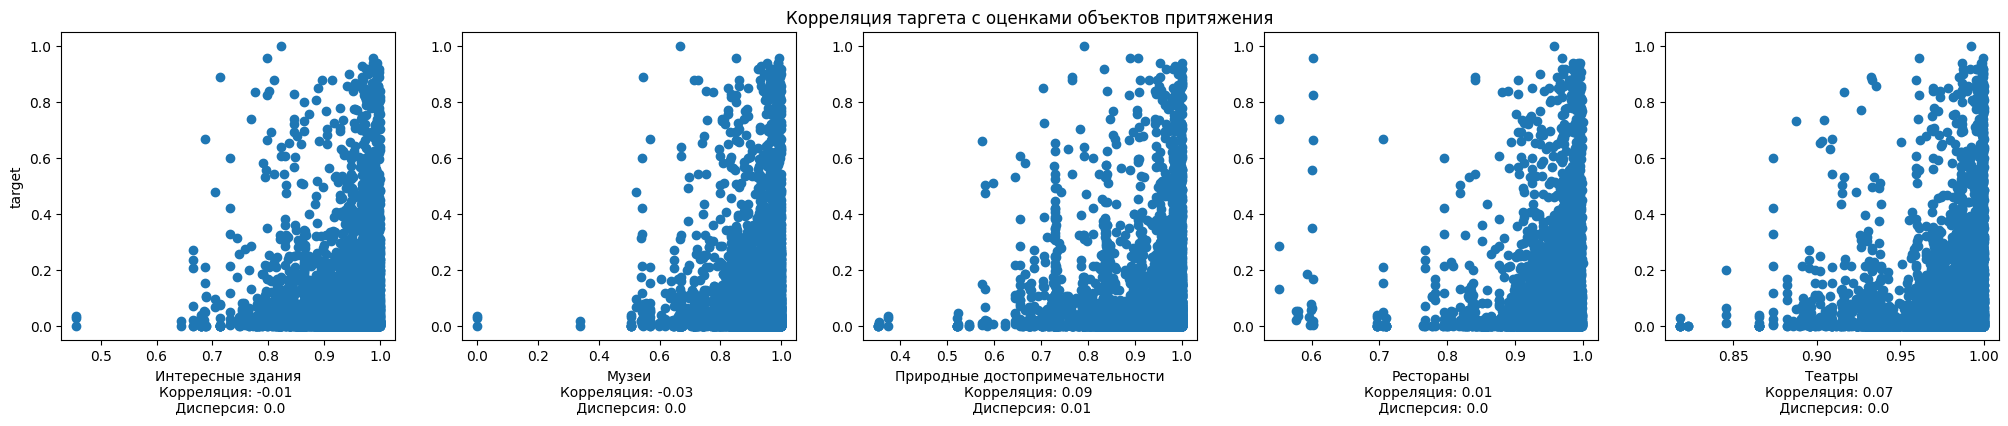

In [39]:
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
cols = ['Интересные здания',	'Музеи',	'Природные достопримечательности',	'Рестораны',	'Театры']
for i in range(5):
  col = cols[i]
  axes[i].scatter(hotels_w[col], hotels_w['target'])
  axes[i].set_xlabel(f'{col}\nКорреляция: {np.round(hotels_w["target"].corr(hotels_w[col]), 2)} \n Дисперсия: {np.round(np.var(hotels_w[col]), 2)}')
axes[2].set_title('Корреляция таргета с оценками объектов притяжения')
axes[0].set_ylabel('target')
fig.show()

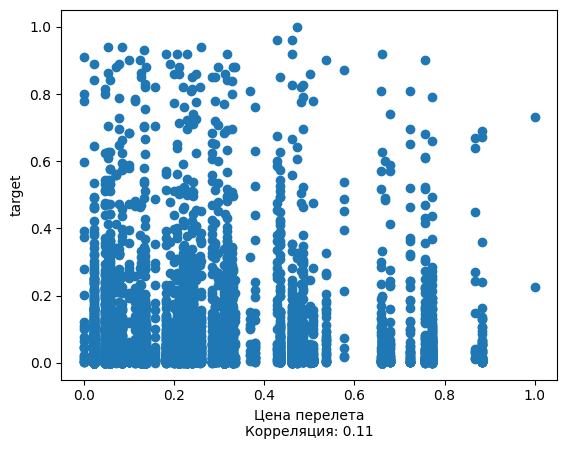

In [40]:
plt.scatter(hotels_w['flight_price_weighted'], hotels_w['target'])
plt.xlabel(f'Цена перелета\nКорреляция: {np.round(hotels_w["target"].corr(hotels_w['flight_price_weighted']), 2)}')
plt.ylabel('target')
plt.show()

In [41]:
city_corr = hotels_w.groupby(by=['city_name']).agg({'price_per_night': 'mean', 'Интересные здания': 'mean',	'Музеи': 'mean',	'Природные достопримечательности': 'mean',	'Рестораны': 'mean', 'Театры': 'mean', 'flight_price_weighted': 'mean',	'target': 'mean'}).reset_index()

In [42]:
city_corr.head(3)

,city_name,price_per_night,Интересные здания,Музеи,Природные достопримечательности,Рестораны,Театры,flight_price_weighted,target
0,Абакан,4189.833333,0.785965,0.835842,0.878365,0.595169,0.957136,0.461033,0.232581
1,Анадырь,11256.000000,0.999953,0.999999,NaN,0.999987,NaN,1.000000,0.477491
2,Анапа,6421.603412,0.927116,0.891244,0.896590,0.940099,0.974936,0.661150,0.016231


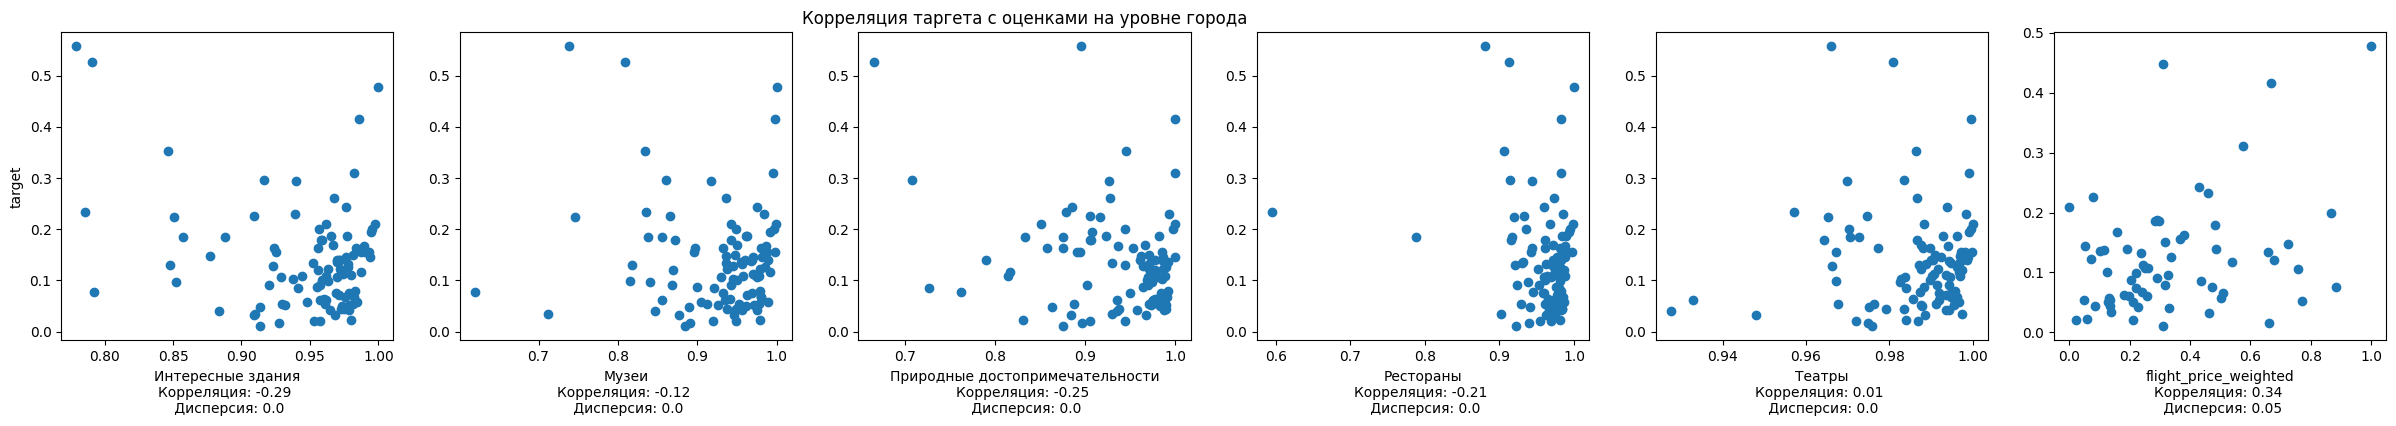

In [43]:
cols = ['Интересные здания',	'Музеи',	'Природные достопримечательности',	'Рестораны',	'Театры',	'flight_price_weighted']
dct = {}
fig, axes = plt.subplots(1, 6, figsize=(30, 4))
for i in range(6):
  col = cols[i]
  if i < 5:
    dct[col] = abs(city_corr["target"].corr(city_corr[col]))
  axes[i].scatter(city_corr[col], city_corr['target'])
  axes[i].set_xlabel(f'{col}\nКорреляция: {np.round(city_corr["target"].corr(city_corr[col]), 2)} \n Дисперсия: {np.round(np.var(city_corr[col]), 2)}')
axes[2].set_title('Корреляция таргета с оценками на уровне города')
axes[0].set_ylabel('target')
fig.show()

На уровне городов шум убран. Самое важное: Дешевые билеты (0.34), Интересные здания (-0.29), Природа (-0.25), Рестораны (-0.21), Музеи (-0.12). Театры не оказывают влияния

## Выбираем города и точки для открытия ##

In [44]:
city_corr['weighted_score'] = (city_corr['flight_price_weighted'] * 0.34) + ((1 - city_corr['Интересные здания']) * 0.29)  + ((1 - city_corr['Природные достопримечательности']) * 0.25) + ((1 - city_corr['Рестораны']) * 0.21) + ((1 - city_corr['Музеи']) * 0.12)
city_corr = city_corr.sort_values(by='weighted_score')[:20]
city_corr

,city_name,price_per_night,Интересные здания,Музеи,Природные достопримечательности,Рестораны,Театры,flight_price_weighted,target,weighted_score
27,Казань,6859.175644,0.981264,0.976947,0.970422,0.983936,0.991285,0.047665,0.053856,0.035174
93,Чебоксары,4117.823529,0.976037,0.970521,0.985952,0.976517,0.992472,0.053249,0.144811,0.037035
46,Москва,5332.632047,0.952881,0.948551,0.944204,0.954617,0.972046,0.023039,0.020533,0.051151
79,Сургут,3795.711864,0.963328,0.937366,0.986319,0.951736,0.987545,0.072329,0.122985,0.056299
4,Архангельск,4198.764706,0.970840,0.967178,0.985747,0.976217,0.994226,0.114130,0.136827,0.059757
71,Саранск,5943.375000,0.961914,0.941659,0.851473,0.968221,0.988274,0.000000,0.209151,0.061851
22,Екатеринбург,4669.747170,0.972675,0.937569,0.937128,0.984403,0.979144,0.084134,0.043901,0.063015
29,Калуга,3680.464286,0.969910,0.954959,0.991564,0.931876,0.996915,0.101120,0.135677,0.064927
88,Уфа,4591.906250,0.975155,0.948944,0.989603,0.984180,0.983413,0.135250,0.043474,0.065238
69,Самара,4222.941176,0.973120,0.960759,0.983122,0.974674,0.987743,0.127752,0.050123,0.065478


In [45]:
city_to_check = list(city_corr['city_name'][:7].values)
data = [['Город', 'lat', 'lon']]
for city in city_to_check:
  needed_sights = sightseens[sightseens['city'] == city]
  needed_sights = needed_sights[needed_sights['I'] > 0]
  needed_sights['I'] = needed_sights.apply(lambda x: x['I'] * (dct[x['rubric']])/max(list(dct.values())), axis=1)
  lat = np.round(np.average(needed_sights['lat'], weights=needed_sights['I']), 2)
  lon = np.round(np.average(needed_sights['lon'], weights=needed_sights['I']), 2)
  data.append([city, lat, lon])

In [46]:
pd.DataFrame(data[1:], columns=data[0])

,Город,lat,lon
0,Казань,55.80,49.09
1,Чебоксары,56.15,47.25
2,Москва,55.74,37.61
3,Сургут,61.25,73.35
4,Архангельск,64.54,40.41
5,Саранск,54.18,45.18
6,Екатеринбург,56.85,60.59


In [49]:
hotels_w.to_excel('results.xlsx', index=False)